In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [178]:
picher_file_path = "data/batter_stats_2017.csv"
batter_file_path = "data/batter_stats_2017.csv"
picher = pd.read_csv(picher_file_path)
batter = pd.read_csv(batter_file_path)

In [179]:
picher.columns

Index(['선수명', '팀명', '경기', '타석', '타수', '안타', '홈런', '득점', '타점', '볼넷', '삼진', '도루',
       'BABIP', '타율', '출루율', '장타율', 'OPS', 'wOBA', 'WAR', '연봉(2018)',
       '연봉(2017)'],
      dtype='object')

In [180]:
batter.columns

Index(['선수명', '팀명', '경기', '타석', '타수', '안타', '홈런', '득점', '타점', '볼넷', '삼진', '도루',
       'BABIP', '타율', '출루율', '장타율', 'OPS', 'wOBA', 'WAR', '연봉(2018)',
       '연봉(2017)'],
      dtype='object')

In [181]:
picher.head()

,선수명,팀명,경기,타석,타수,안타,홈런,득점,타점,볼넷,...,도루,BABIP,타율,출루율,장타율,OPS,wOBA,WAR,연봉(2018),연봉(2017)
0,최정,SK,130,527,430,136,46,89,113,70,...,1,0.316,0.316,0.427,0.684,1.111,0.442,7.30,120000,120000
1,최형우,KIA,142,629,514,176,26,98,120,96,...,0,0.362,0.342,0.450,0.576,1.026,0.430,7.20,150000,150000
2,박건우,두산,131,543,483,177,20,91,78,41,...,20,0.39,0.366,0.424,0.582,1.006,0.424,7.04,37000,19500
3,나성범,NC,125,561,498,173,24,103,99,48,...,17,0.413,0.347,0.415,0.584,0.999,0.416,5.64,43000,35000
4,손아섭,롯데,144,667,576,193,20,113,80,83,...,25,0.374,0.335,0.420,0.514,0.934,0.398,5.60,150000,65000


In [182]:
print(picher.shape)
#영상에서는 (152,22)으로 나오긴 했는데... 40개가 더 있는건지는 잘 모르겠다

(191, 21)


In [183]:
import matplotlib as mpl
set(sorted([f.name for f in mpl.font_manager.fontManager.ttflist]))
#폰트 찾기

{'.Aqua Kana',
 '.CJK Symbols Fallback HK',
 '.DecoType Nastaleeq Urdu UI',
 '.Keyboard',
 '.New York',
 '.SF Arabic',
 '.SF Arabic Rounded',
 '.SF Armenian',
 '.SF Armenian Rounded',
 '.SF Camera',
 '.SF Compact',
 '.SF Compact Rounded',
 '.SF Georgian',
 '.SF Georgian Rounded',
 '.SF Hebrew',
 '.SF Hebrew Rounded',
 '.SF NS Mono',
 '.SF NS Rounded',
 '.SF Numeric',
 '.ThonburiUI',
 'Academy Engraved LET',
 'Adelle Sans Devanagari',
 'AkayaKanadaka',
 'AkayaTelivigala',
 'Al Bayan',
 'Al Nile',
 'Al Tarikh',
 'American Typewriter',
 'Andale Mono',
 'Annai MN',
 'Apple Braille',
 'Apple Chancery',
 'Apple LiGothic',
 'Apple LiSung',
 'Apple SD Gothic Neo',
 'Apple Symbols',
 'AppleGothic',
 'AppleMyungjo',
 'Arial',
 'Arial Black',
 'Arial Hebrew',
 'Arial Narrow',
 'Arial Rounded MT Bold',
 'Arial Unicode MS',
 'Arima Koshi',
 'Arima Madurai',
 'Athelas',
 'Avenir',
 'Avenir Next',
 'Avenir Next Condensed',
 'Ayuthaya',
 'BIZ UDGothic',
 'BIZ UDMincho',
 'BM Dohyeon',
 'BM Hanna 11yrs

In [184]:
#이건 그냥 우리학교 폰트로 설정하는 코드 
import matplotlib as mpl
import matplotlib.font_manager as fm
from pathlib import Path

font_path = next(
    p for p in (Path.home() / "Library/Fonts").glob("*.otf")
    if p.name.endswith("L.otf") and "외대" in p.name
)

fm.fontManager.addfont(str(font_path))
font_name = fm.FontProperties(fname=str(font_path)).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

In [185]:
picher['연봉(2018)'].describe()
#먼저 우리가 볼 연봉이라는 데이터의 대략적인 정보를 describe으로 살펴보자

count       191.000000
mean      20625.654450
std       31978.855209
min        2700.000000
25%        4200.000000
50%        7500.000000
75%       25000.000000
max      250000.000000
Name: 연봉(2018), dtype: float64

<Axes: >

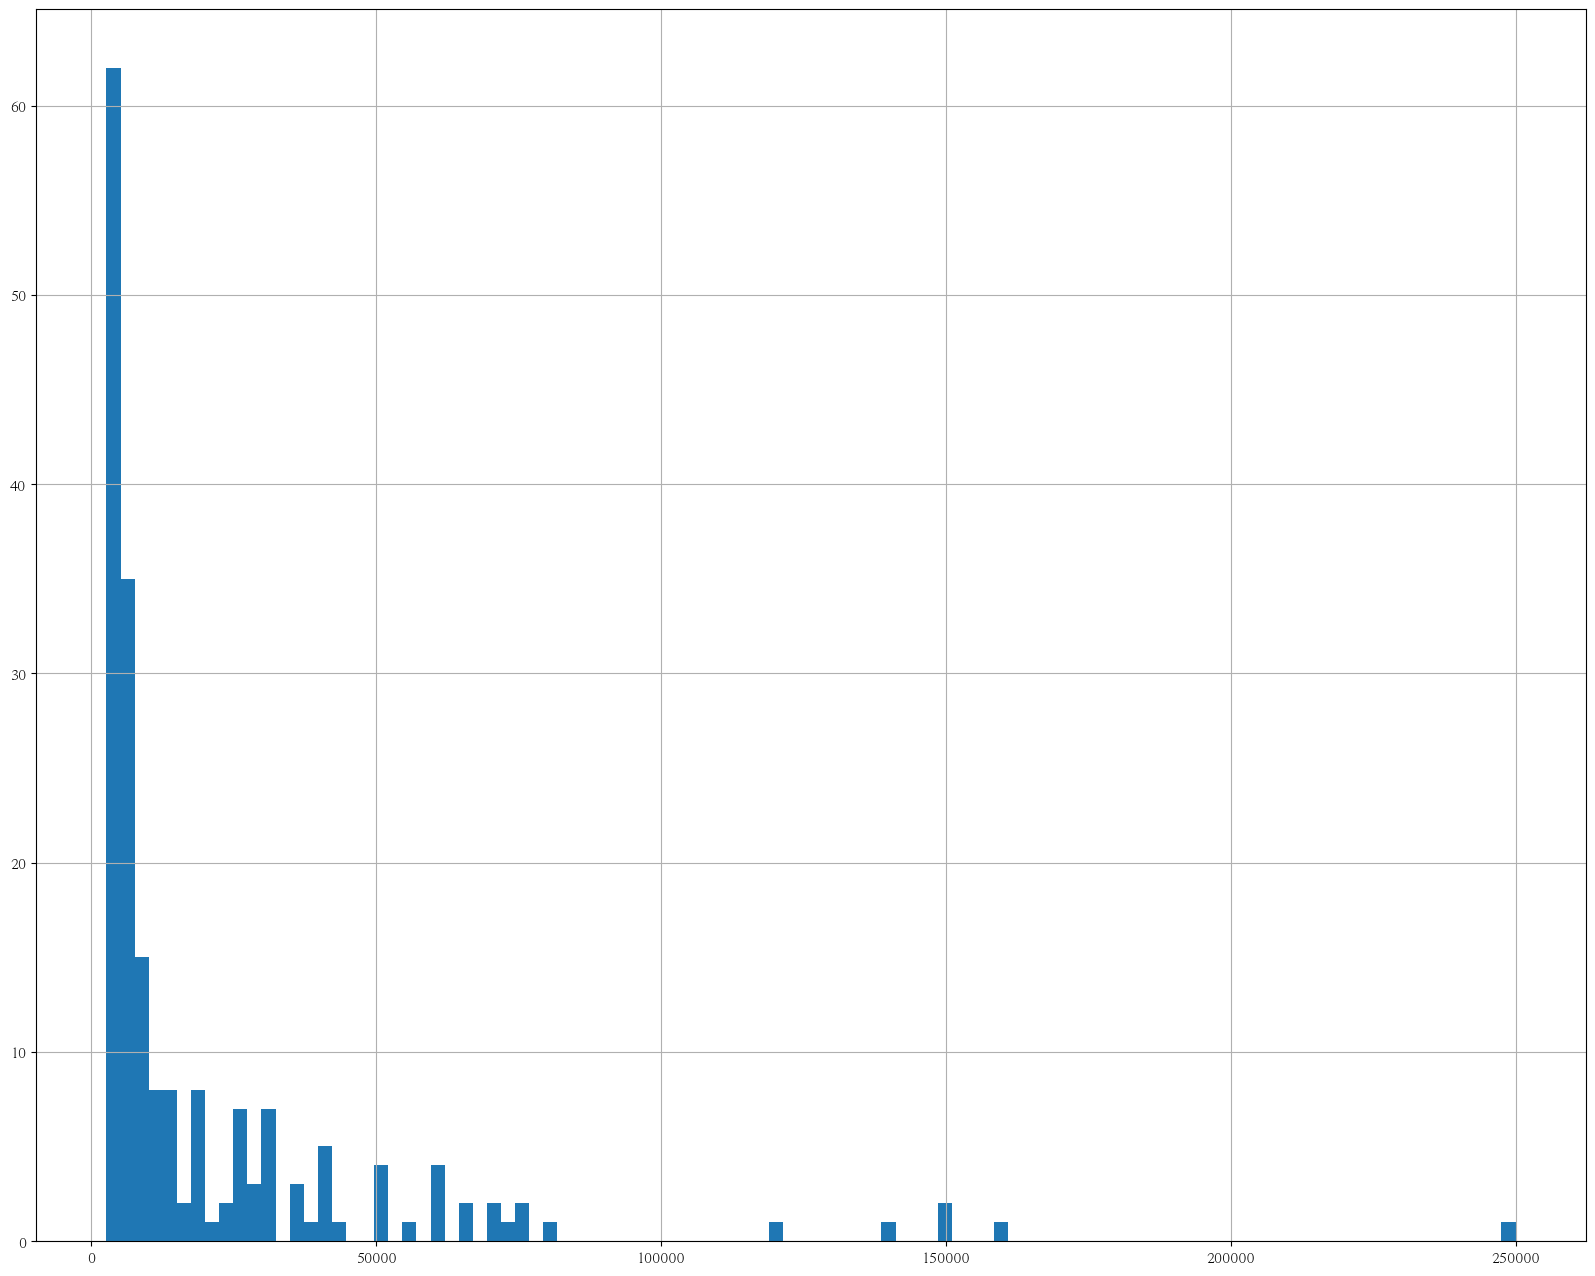

In [186]:
picher['연봉(2018)'].hist(bins=100)
#연봉의 분포를 히스토그램으로 그려보자. bins는 막대의 개수
#100개로 나눠봤음

,선수명,연봉(2018)
16,이대호,250000
22,김태균,160000
4,손아섭,150000
1,최형우,150000
10,러프,140000
0,최정,120000
17,박용택,80000
6,버나디나,75000
40,박석민,75000
24,번즈,73000


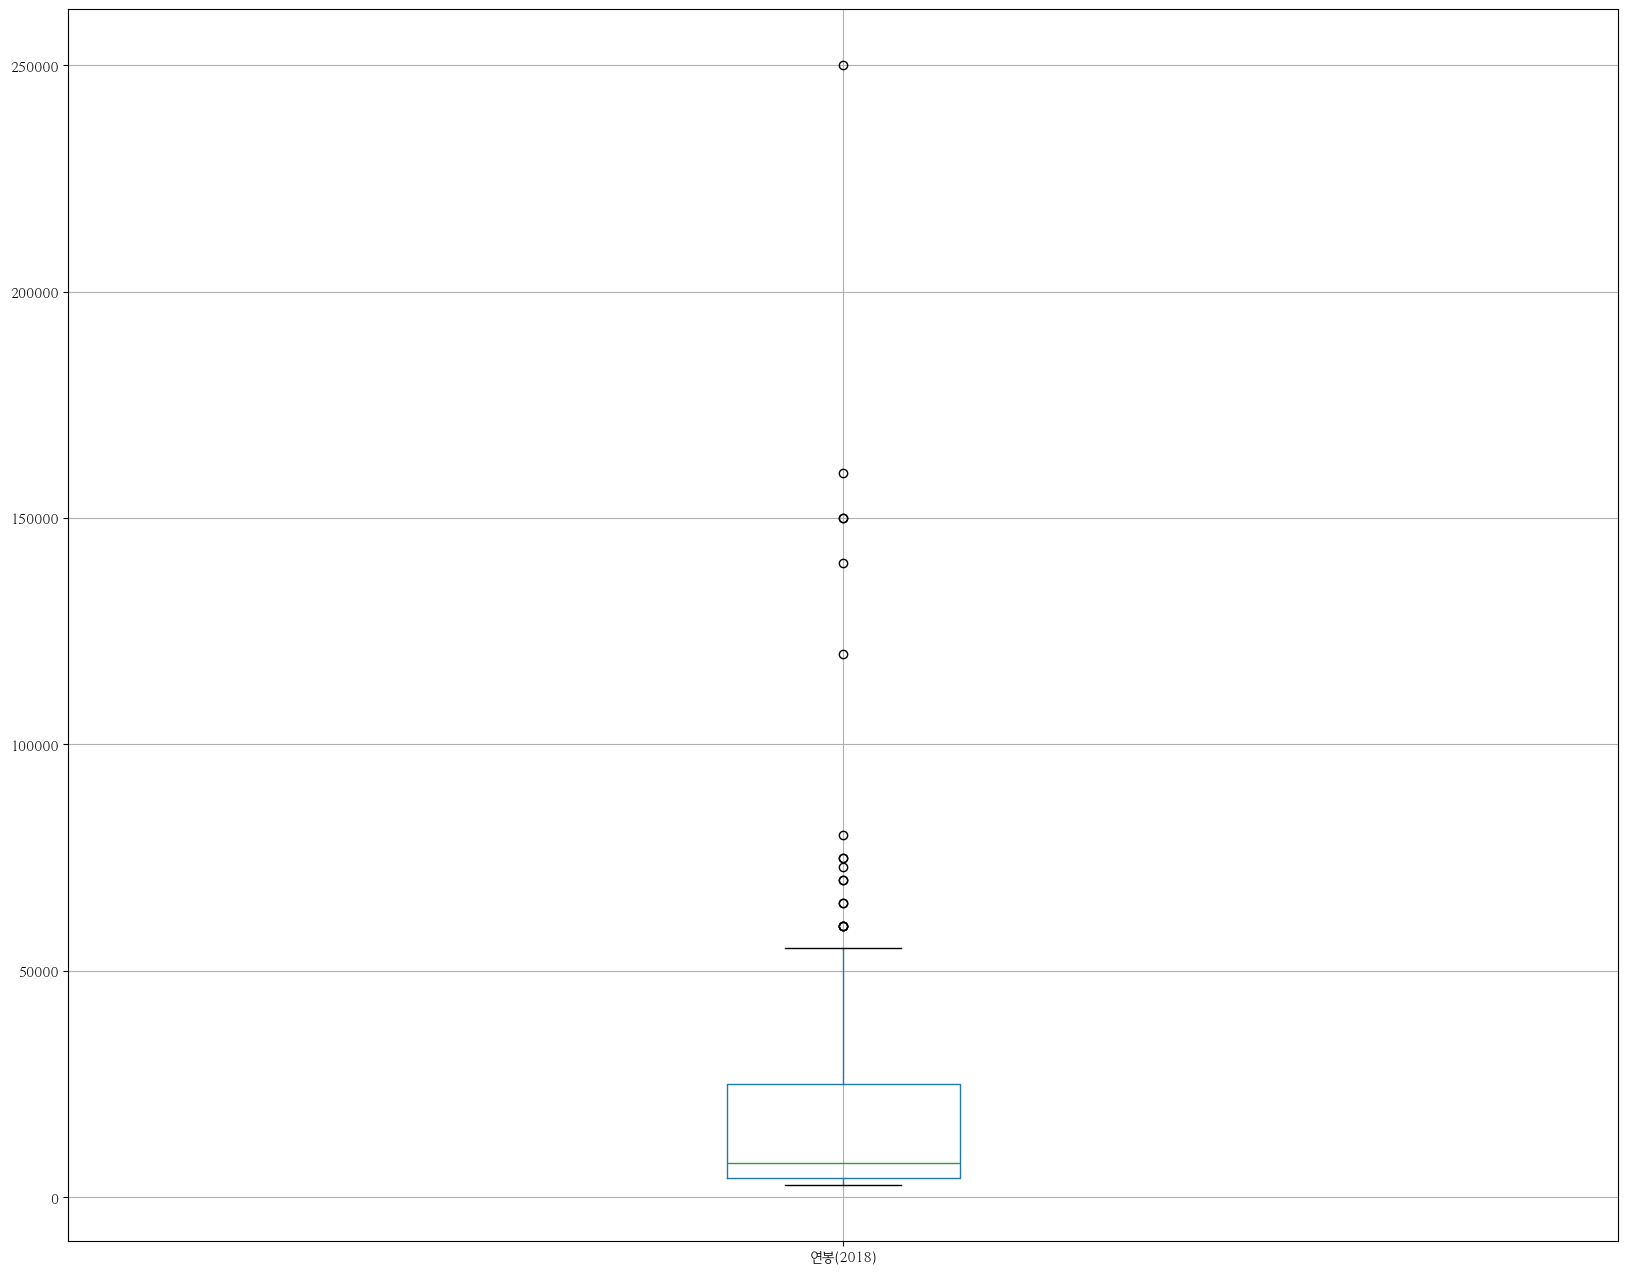

In [187]:
col = "연봉(2018)"
# boxplot 기준 이상치 확인(IQR 방식)
# 원래 영상에서는 boxplot으로 그려보는 것까지 했는데, 이상치가 누군지 궁금해서 IQR 방식을 이용해봤음
Q1 = picher[col].quantile(0.25)
Q3 = picher[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

picher.boxplot(column=[col])

outliers = picher[(picher[col] < lower) | (picher[col] > upper)]
#이상치는 IQR 방식으로 구한 lower, upper보다 작은 값이나 큰 값으로 정의
outliers[["선수명", col]].sort_values(col, ascending=False)

#이대호가 1위이라고 한다...
#대단하네...

In [188]:
#회귀 분석에 사용할 피처를 한번 살펴보고 어떤걸 사용하면 좋을지 생각해보자

picher_features_df = picher[['선수명', '팀명', '경기', '타석', '타수', '안타', '홈런', '득점', '타점', '볼넷', '삼진', '도루',
       'BABIP', '타율', '출루율', '장타율', 'OPS', 'wOBA', 'WAR', '연봉(2018)',
       '연봉(2017)']]

In [189]:
# 근데 난 이 용어들이 뭔지 잘 모름.
# 그래서 제미나이한테 정리해달라고 했음

# 선수명: 선수 이름
# 팀명: 소속 팀 이름
# 경기: 출전 경기 수
# 타석: 타자가 타석에 들어선 총 횟수
# 타수: 실제로 타격 기회로 기록된 횟수
# 볼넷, 희생번트 같은 건 보통 타수에 안 들어감
# 안타: 공을 쳐서 1루 이상 살아나간 횟수
# 홈런: 홈런 개수
# 득점: 선수가 홈까지 들어와 점수를 낸 횟수
# 타점: 이 선수의 타격으로 팀 동료가 홈에 들어와 점수가 난 횟수
# 볼넷: 투수가 공 4개를 던져 타자가 1루로 나간 횟수
# 삼진: 스트라이크 3개로 아웃된 횟수
# 도루: 주자가 다음 베이스로 훔쳐 간 횟수

# 타격 비율 지표들:
# BABIP: 홈런 제외, 인플레이 타구가 안타가 된 비율
# 쉽게 말하면 “친 공이 수비 사이로 빠져 안타가 되는 운/능력 섞인 지표”
# 타율: 안타 / 타수
# 예: 0.300이면 10타수 3안타 정도
# 출루율: 얼마나 자주 1루 이상 나가는지
# 안타뿐 아니라 볼넷도 반영
# 장타율: 한 번 칠 때 얼마나 많은 베이스를 얻는지
# 2루타, 3루타, 홈런이 높게 반영됨
# OPS: 출루율 + 장타율
# 타자의 공격력을 간단히 보는 대표 지표
# wOBA: 타격 결과별 가치를 다르게 계산한 공격 지표
# 단타, 2루타, 홈런, 볼넷의 실제 득점 기여도를 반영
# WAR: 대체 선수 대비 승리 기여도
# 쉽게 말하면 “이 선수가 팀 승리에 얼마나 더 보탬이 됐는지”

In [190]:
def plot_hist_each_column(df):
    plt.rcParams['figure.figsize'] = [20,16]
    fig = plt.figure(1)
    
    for _ in range(len(df.columns)):
        ax = fig.add_subplot(5, 5, _+1)
        plt.hist(df[df.columns[_]],bins=50)
        ax.set_title(df.columns[_])
    plt.show()

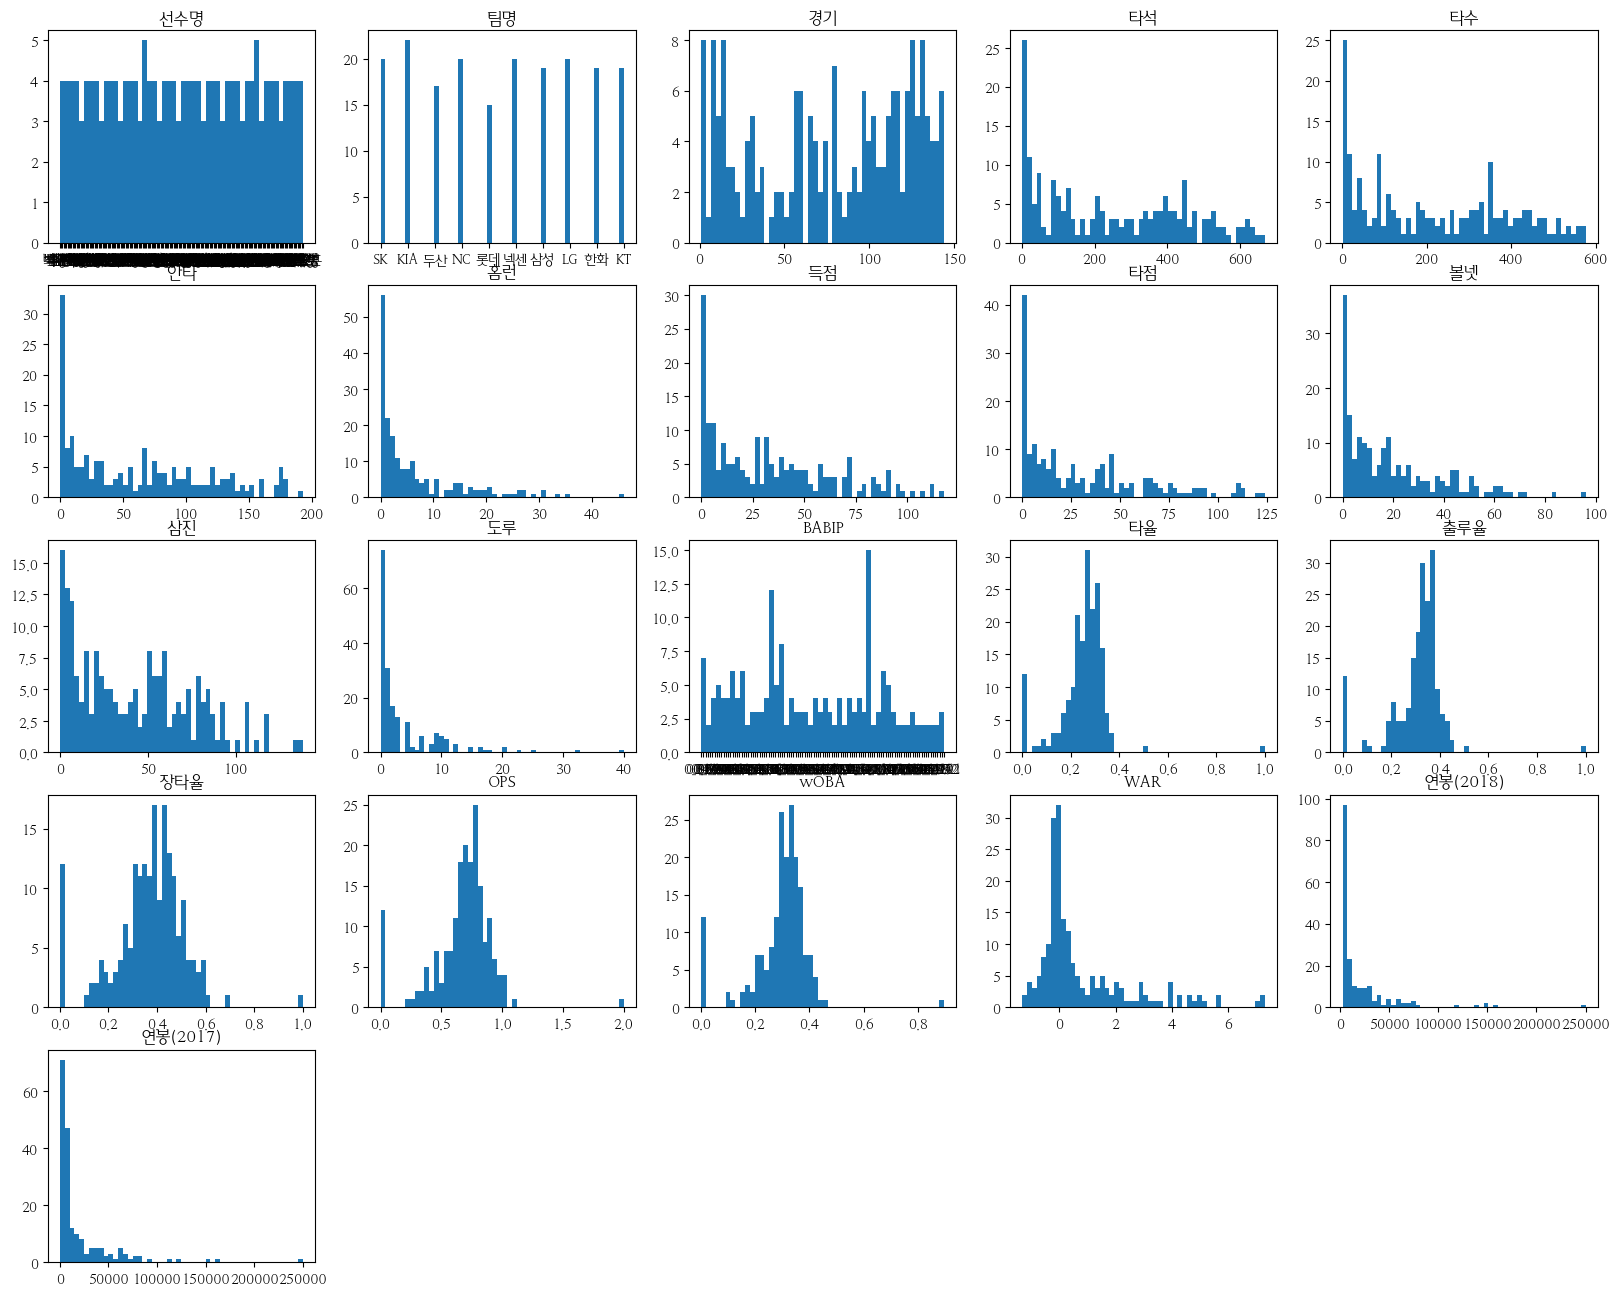

In [191]:
plot_hist_each_column(picher_features_df)

#이렇게 각 피처의 분포를 한눈에 확인할수 있기는한데
#저렇게 검정색이 겹쳐보이는건 선수명이 들어가있어서 겹처서 까맣게 출력되는중...
#한눈에 정규성을 가진것들을 확인할수있다는 장점이 있을거 같긴 하다

In [192]:
pd.options.mode.chained_assignment = None
#판다스는 이제 복사본인지, 원본 일부를 바라보는 view인지 애매한 경우에 사용자한테 경고로 SettingWithCopyWarning을 띄우는데...
#우리는 이걸 꺼버려서 그냥 편하게 작업해보자

In [193]:
#피처 각각에 대한 스케일링을 한번씩 해준다
def standard_scaling(df, scale_columns):
    df = df.copy()
    df[scale_columns] = df[scale_columns].apply(pd.to_numeric, errors="coerce")

    for col in scale_columns:
        series_mean = df[col].mean()
        series_std = df[col].std()
        df[col] = (df[col] - series_mean) / series_std

    return df

In [194]:
scale_columns = ['경기', '타석', '타수', '안타', '홈런', '득점', '타점', '볼넷', '삼진', '도루',
       'BABIP', '타율', '출루율', '장타율', 'OPS', 'wOBA', 'WAR', '연봉(2018)',
       '연봉(2017)']
picher_df = standard_scaling(picher, scale_columns)

In [195]:
picher_df = picher_df.rename(columns={'연봉(2018)': 'y'})
picher_df.head(5)

,선수명,팀명,경기,타석,타수,안타,홈런,득점,타점,볼넷,...,도루,BABIP,타율,출루율,장타율,OPS,wOBA,WAR,y,연봉(2017)
0,최정,SK,1.149505,1.434367,1.231734,1.344928,4.621390,1.871933,2.601791,2.595310,...,-0.448042,0.101238,0.647202,1.064628,2.156064,1.732763,1.380264,3.857382,3.107502,3.264136
1,최형우,KIA,1.413314,1.952604,1.716832,2.074446,2.289944,2.174277,2.823399,3.927160,...,-0.615839,0.460774,0.899677,1.267954,1.424382,1.397014,1.268659,3.798140,4.045622,4.234754
2,박건우,두산,1.171489,1.515659,1.537807,2.092684,1.590510,1.939120,1.493746,1.109785,...,2.740086,0.679622,1.132730,1.038107,1.465031,1.318014,1.212856,3.703353,0.512037,0.012569
3,나성범,NC,1.039584,1.607113,1.624432,2.019732,2.056799,2.342246,2.158573,1.468360,...,2.236697,0.859390,0.948230,0.958544,1.478581,1.290364,1.138453,2.873969,0.699661,0.514054
4,손아섭,롯데,1.457283,2.145672,2.074881,2.384491,1.590510,2.678185,1.557063,3.261235,...,3.579067,0.554566,0.831703,1.002746,1.004343,1.033615,0.971045,2.850272,4.045622,1.484672


In [196]:
# 팀명은 글자라서 이해못하니깐 원핫인코딩으로 바꿔주자
# 팀 컬럼을 전부 넣으면 하나가 나머지로 설명돼서 애매해질 수 있으니 기준팀 하나는 빼고 가자
team_columns = pd.get_dummies(picher["팀명"], dtype=int).columns
#근데 코드에 자꾸 오류가 떠서...오류 무시하는 코드 추가함
picher_df = picher_df.drop(columns=["팀명"], errors="ignore")
picher_df = picher_df.drop(columns=team_columns, errors="ignore")
picher_df = picher_df.join(team_encoding)

In [197]:
team_encoding.head(5)

,KT,LG,NC,SK,넥센,두산,롯데,삼성,한화
0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0
3,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0


In [198]:
picher_df.head()

,선수명,경기,타석,타수,안타,홈런,득점,타점,볼넷,삼진,...,연봉(2017),KT,LG,NC,SK,넥센,두산,롯데,삼성,한화
0,최정,1.149505,1.434367,1.231734,1.344928,4.621390,1.871933,2.601791,2.595310,1.960099,...,3.264136,0,0,0,1,0,0,0,0,0
1,최형우,1.413314,1.952604,1.716832,2.074446,2.289944,2.174277,2.823399,3.927160,1.204511,...,4.234754,0,0,0,0,0,0,0,0,0
2,박건우,1.171489,1.515659,1.537807,2.092684,1.590510,1.939120,1.493746,1.109785,0.660487,...,0.012569,0,0,0,0,0,1,0,0,0
3,나성범,1.039584,1.607113,1.624432,2.019732,2.056799,2.342246,2.158573,1.468360,2.232111,...,0.514054,0,0,1,0,0,0,0,0,0
4,손아섭,1.457283,2.145672,2.074881,2.384491,1.590510,2.678185,1.557063,3.261235,1.627640,...,1.484672,0,0,0,0,0,0,1,0,0


In [199]:
#이제 회귀 분석을 해보자

from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# X에는 연봉을 예측할 때 참고할 숫자 변수들만 남겨보자
# y는 내가 맞추고 싶은 값이라서 아까 이름 바꾼 연봉(2018)
X = picher_df[picher_df.columns.difference(["선수명", "y"])]
y = picher_df["y"]

# BABIP에 '-'가 하나 껴 있어서 숫자로 바꾸면 NaN이 생긴다는걸 확인함
# LinearRegression할때 결측지가 있으면 오류가 계속 났음
# 어디서 빠지는지 보고 그 행만 빼고 진행해보자
model_df = pd.concat([X, y], axis=1)
missing_before_split = model_df.isna().sum()

model_df = model_df.dropna()
X = model_df.drop(columns=["y"])
y = model_df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [200]:
# 일단 선형회귀 모델 한번 학습시켜보자
# 처음에는 피처를 다 넣고 돌려본 다음에 뭐가 영향이 큰지 확인해보는 식으로 ㄱㄱ
lr = linear_model.LinearRegression()
model = lr.fit(X_train, y_train)

In [201]:
# 학습된 계수를 바로 확인해보자
# 영상에는 계수만 봤는데 조금 불친절하니깐 컬럼명이랑 같이 묶어서 보자
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": lr.coef_,
})
coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
#ascending=False로 해서 큰 순서대로 정렬
#wOBA가 가장 큰데, 이건 wOBA: 타격 결과별 가치를 다르게 계산한 공격 지표 라고 한다

,feature,coef
7,wOBA,2.100918
21,타석,-1.707933
22,타수,1.282850
20,출루율,-1.220716
18,연봉(2017),0.850964
4,OPS,-0.758994
19,장타율,-0.366283
14,볼넷,0.349362
13,롯데,0.270908
17,안타,0.261592


In [202]:
# 이제 모델이 얼마나 맞추는지 점수로 확인해보자
# y도 표준화된 값이라 RMSE도 원래 연봉 단위는 아님
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

eval_df = pd.DataFrame({
    "data": ["train", "test"],
    "RMSE": [
        sqrt(mean_squared_error(y_train, y_train_pred)),
        sqrt(mean_squared_error(y_test, y_test_pred)),
    ],
    "R2": [
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred),
    ],
})

eval_df
#생각보다 괜찮은 결과를 보여준다

,data,RMSE,R2
0,train,0.227993,0.930590
1,test,0.295912,0.956077


In [203]:
import statsmodels.api as sm

# sklearn은 예측하기엔 편한데 p-value 같은 건 statsmodels가 더 보기 편하다고 한다...
# 여기서는 어떤 변수가 좀 의미 있어 보이는지 감만 잡아보면 될 듯

X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
model_sm.summary()
# 즉 내가 만든 모델은 2018년 연봉의 약 93.1%를 설명한다는 뜻. 꽤 높다고 할 수 있음
# Adj.R-squared는 변수 개수까지 고려할때 보는거라 더 정확함
# F-statistic는 모델이 유의미한지 보는 지표인데, p-value가 e-60, 즉 거의 0이라...유의미하다고 할 수 있음

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     64.46
Date:                Mon, 25 May 2026   Prob (F-statistic):           3.98e-60
Time:                        19:33:37   Log-Likelihood:                 9.0443
No. Observations:                 152   AIC:                             35.91
Df Residuals:                     125   BIC:                             117.6
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0064      0.065     -0.098      0.922      -0.135       0.122
BABIP         -0.0090      0.046     -0.196      0.845      -0.099       0.081
KT            -0.0598      0.101     -0.592      0.555      -0.260       0.140
LG             0.0141      0.095      0.148      0.883      -0.175       0.203
NC            -0.0958      0.094     -1.021      0.309      -0.281       0.090
OPS           -0.7590      0.420     -1.808      0.073      -1.590       0.072
SK            -0.0105      0.100     -0.105      0.917      -0.209       0.188
WAR            0.0700      0.097      0.720      0.473      -0.122       0.262
wOBA           2.1009      1.209      1.738      0.085      -0.292       4.494
경기             0.0424      0.085      0.499      0.619      -0.126       0.211
넥센            -0.0427      0.091     -0.469      0.640      -0.223       0.138
도루             0.0363      0.034      1.071      0.286      -0.031       0.103
두산             0.0638      0.098      0.649      0.517      -0.131       0.258
득점            -0.0598      0.105     -0.568      0.571      -0.268       0.149
롯데             0.2709      0.101      2.682      0.008       0.071       0.471
볼넷             0.3494      0.113      3.104      0.002       0.127       0.572
삼성             0.0096      0.094      0.103      0.918      -0.175       0.195
삼진            -0.0388      0.067     -0.582      0.562      -0.171       0.093
안타             0.2616      0.333      0.785      0.434      -0.398       0.921
연봉(2017)       0.8510      0.039     21.755      0.000       0.774       0.928
장타율           -0.3663      0.233     -1.570      0.119      -0.828       0.095
출루율           -1.2207      0.651     -1.876      0.063      -2.508       0.067
타석            -1.7079      1.170     -1.459      0.147      -4.024       0.609
타수             1.2828      1.216      1.055      0.293      -1.123       3.689
타율             0.1743      0.129      1.356      0.177      -0.080       0.429
타점            -0.0576      0.122     -0.473      0.637      -0.299       0.184
한화             0.0369      0.093      0.396      0.693      -0.148       0.222
홈런             0.1270      0.093      1.364      0.175      -0.057       0.311
==============================================================================
Omnibus:                      107.444   Durbin-Watson:                   2.179
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2614.817
Skew:                           2.022   Prob(JB):                         0.00
Kurtosis:                      22.913   Cond. No.                     1.08e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.47e-29. This might indicate

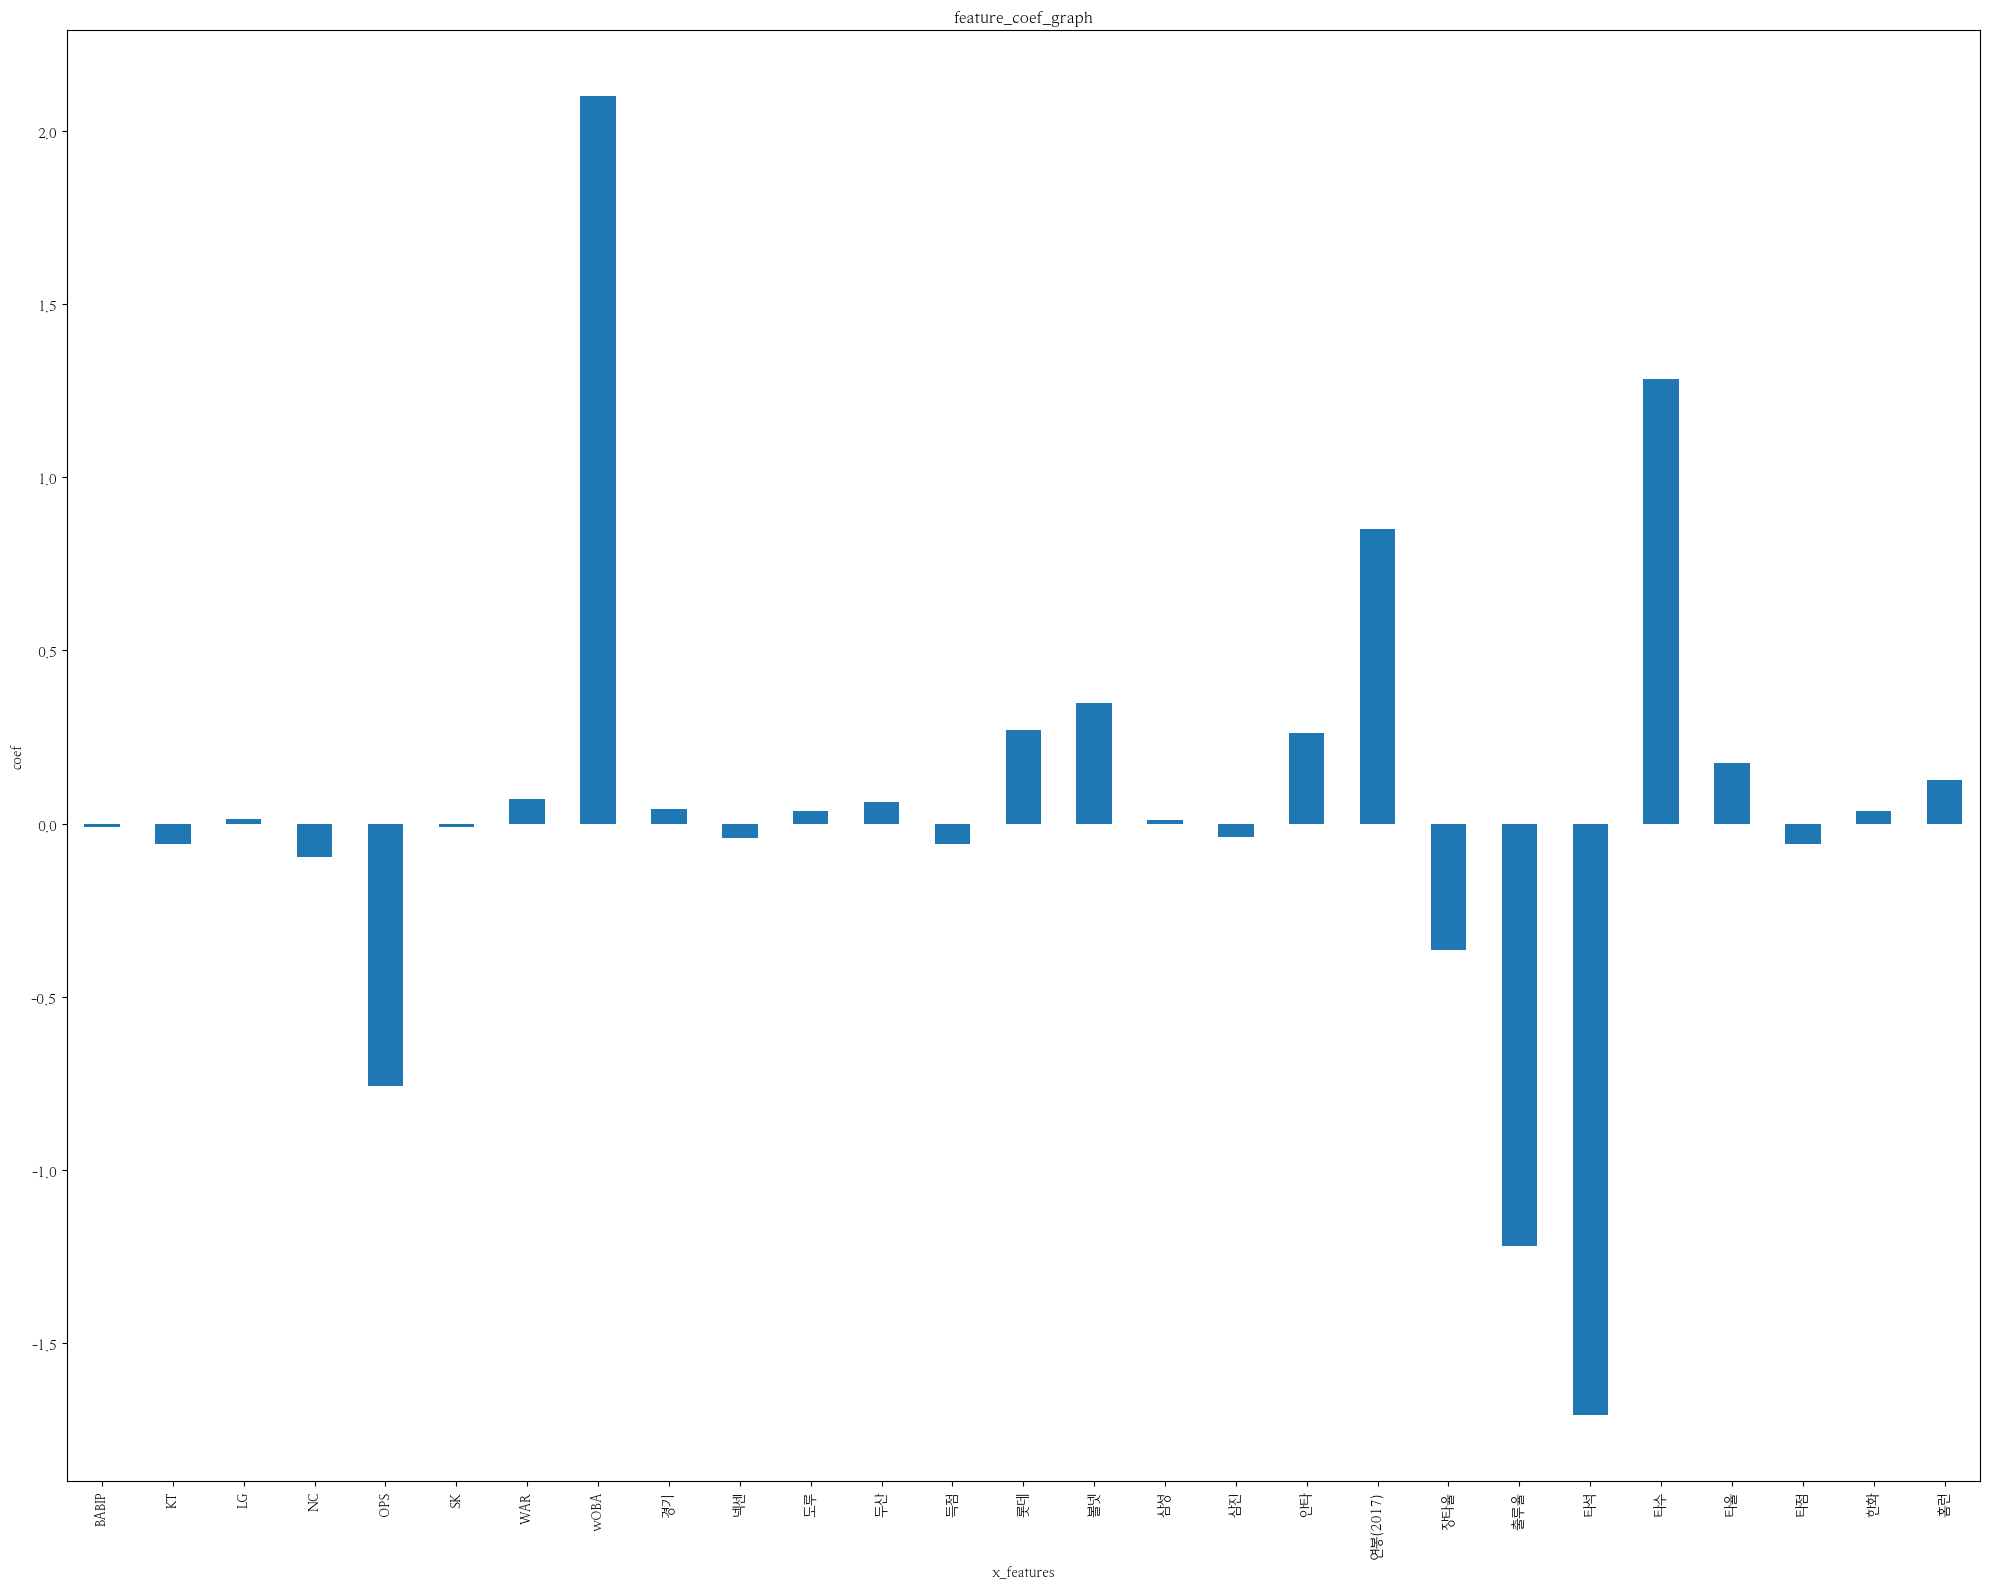

In [204]:
plt.rcParams["figure.figsize"] = [20, 16]

# 회귀 계수를 그래프로 보려고 series 형태로 정리해준다
coefs = model_sm.params.drop(labels="const", errors="ignore")
coefs_series = pd.Series(coefs)

# x축에 변수명을 그대로 붙여서 어떤 계수인지 보이게 하자
x_labels = coefs_series.index.tolist()

# 막대그래프로 보면 어떤 변수가 강한지 더 잘 보임
ax = coefs_series.plot(kind="bar")
ax.set_title("feature_coef_graph")
ax.set_xlabel("x_features")
ax.set_ylabel("coef")
ax.set_xticklabels(x_labels)
plt.tight_layout()

In [205]:
# 이제 실제 연봉이랑 예측 연봉을 선수 이름이랑 같이 비교해보자
# 예측값도 표준화된 값이라 보기 편하게 다시 원래 연봉 단위로 돌려준다
salary_mean = picher["연봉(2018)"].mean()
salary_std = picher["연봉(2018)"].std()

y_test_pred = lr.predict(X_test)
result_df = picher.loc[X_test.index, ["선수명", "팀명", "연봉(2017)", "연봉(2018)"]].copy()
result_df["예측연봉(2018)"] = y_test_pred * salary_std + salary_mean
result_df["예측오차"] = result_df["연봉(2018)"] - result_df["예측연봉(2018)"]

result_df.sort_values("예측오차", key=lambda s: s.abs(), ascending=False).head(10)


,선수명,팀명,연봉(2017),연봉(2018),예측연봉(2018),예측오차
135,이용규,한화,90000,40000,82310.534161,-42310.534161
33,김주찬,KIA,60000,40000,64577.393660,-24577.393660
128,서상우,LG,5500,3500,-15286.193497,18786.193497
37,나주환,SK,15000,30000,18773.891008,11226.108992
130,나종덕,롯데,2700,2800,11819.470997,-9019.470997
1,최형우,KIA,150000,150000,158854.992880,-8854.992880
110,나경민,롯데,3600,5800,13385.955135,-7585.955135
31,정현,KT,2800,7800,364.432460,7435.567540
8,김하성,넥센,22000,32000,38262.235514,-6262.235514
2,박건우,두산,19500,37000,43188.585951,-6188.585951


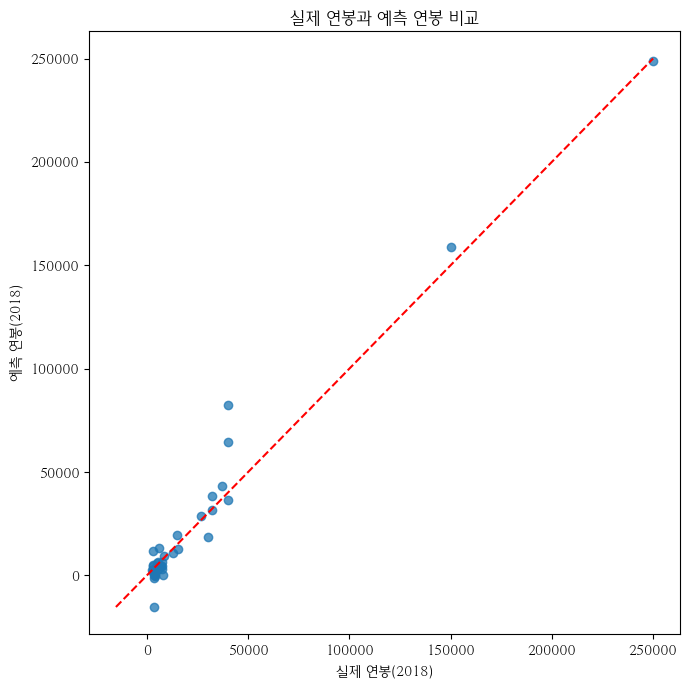

In [206]:
# 표로만 보면 감이 덜 와서 실제 연봉이랑 예측 연봉을 산점도로 찍어보자...
plt.figure(figsize=(7, 7))
plt.scatter(result_df["연봉(2018)"], result_df["예측연봉(2018)"], alpha=0.75)

min_salary = min(result_df["연봉(2018)"].min(), result_df["예측연봉(2018)"].min())
max_salary = max(result_df["연봉(2018)"].max(), result_df["예측연봉(2018)"].max())
plt.plot([min_salary, max_salary], [min_salary, max_salary], color="red", linestyle="--")

plt.xlabel("실제 연봉(2018)")
plt.ylabel("예측 연봉(2018)")
plt.title("실제 연봉과 예측 연봉 비교")
plt.tight_layout()

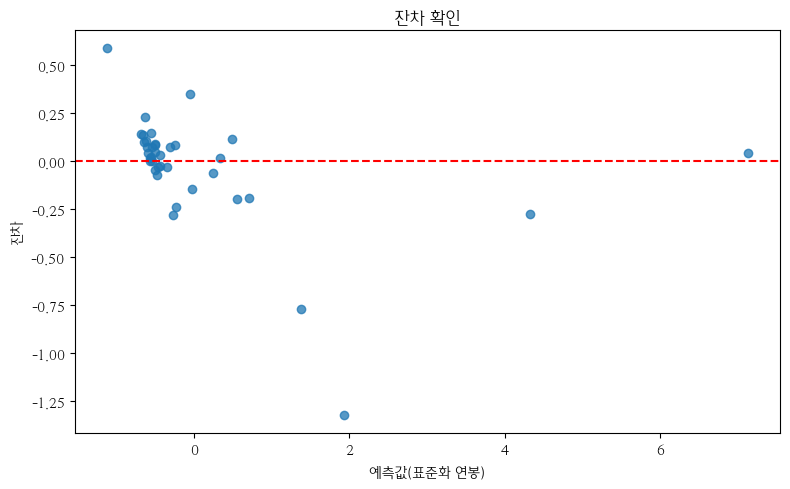

In [207]:
# 잔차가 0 근처에 잘 퍼져 있으면 괜찮고, 한쪽으로 몰리면 뭔가 놓친 패턴이 있을 수 있을거임
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals, alpha=0.75)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("예측값(표준화 연봉)")
plt.ylabel("잔차")
plt.title("잔차 확인")
plt.tight_layout()
# 조금 높은건가?

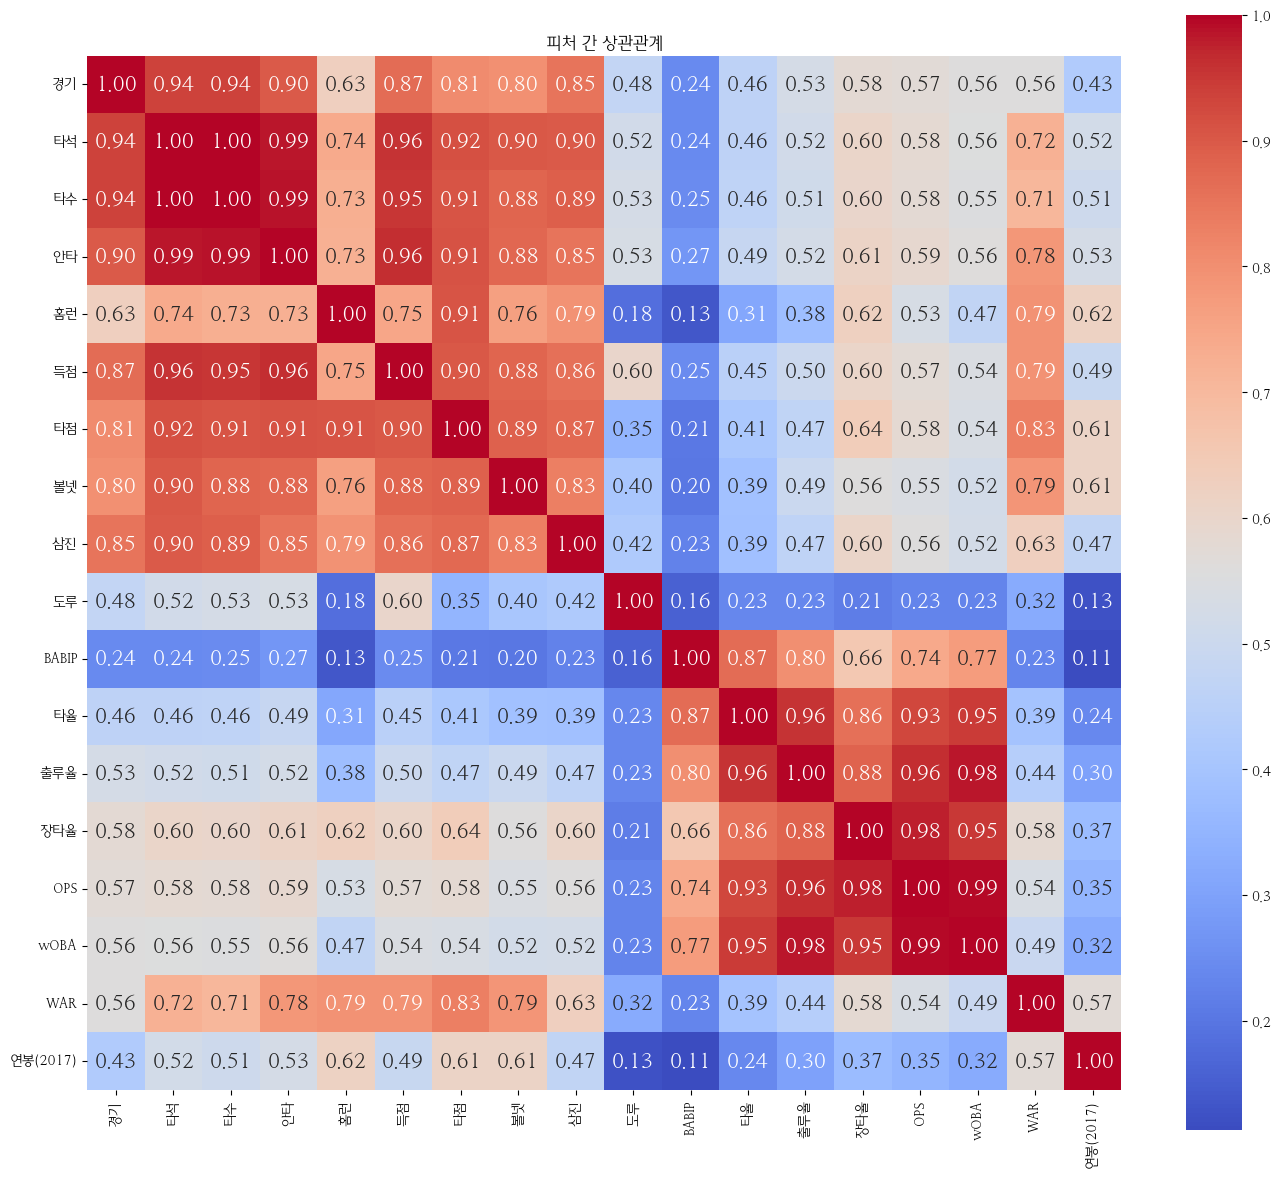

In [208]:
import seaborn as sns

# 변수들끼리 얼마나 비슷하게 움직이는지도 한번 확인
# 출루율, 장타율, OPS는 서로 엮여 있을 것 같아서 상관관계를 확인해보는 게 좋겠듯

corr_columns = [col for col in scale_columns if col != "연봉(2018)"]
corr = picher_df[corr_columns].corr(method="pearson")

#영상에는 -값까지 있었는데, 나는 그냥 양수값만 나오는거 같네...뭔가 이상하긴 한데... 일단은 이렇게 그려보자

plt.figure(figsize=(14, 12))
sns.heatmap(corr,
            cmap="coolwarm", #cbar =True말고 cmap으로 색깔 설정해줬음 이게 더 보기 편한거같음
            annot=True,
            square = True,
            fmt=".2f",
            annot_kws={"size": 15},
            yticklabels=corr_columns,
            xticklabels=corr_columns,)
plt.title("피처 간 상관관계")
plt.tight_layout()
plt.show()

In [209]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 이번엔 VIF로 변수들끼리 너무 겹치는지 확인해보자
# VIF는 variance inflation factor
# 어떤 변수가 다른 변수들이랑 너무 비슷한 정보를 가지고 있는지 확인하는 값

# 만약 VIF가 너무 크면 비슷한 정보를 가진 변수가 많다는 뜻이라 계수 해석이 좀 흔들릴 수 있다

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.8,BABIP
1,1.1,KT
2,1.2,LG
3,1.1,NC
4,inf,OPS
5,1.2,SK
6,21.4,WAR
7,2099.7,wOBA
8,14.2,경기
9,1.1,넥센


In [210]:
# 상관관계랑 VIF를 보니까 타격 지표를 전부 때려넣는 게 꼭 좋아보이진 않는다
# 그래서 이번엔 전년도 연봉, WAR, OPS처럼 대표로 볼 만한 애들만 골라서 다시 비교해보자

selected_features = ["연봉(2017)", "WAR", "볼넷", "홈런", "삼진"]

X_simple = picher_df[selected_features]
y_simple = picher_df["y"]

simple_df = pd.concat([X_simple, y_simple], axis=1).dropna()
X_simple = simple_df[selected_features]
y_simple = simple_df["y"]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=19)

In [211]:
lr = linear_model.LinearRegression()
model = lr.fit(X_train_simple, y_train_simple)

y_train_simple_pred = lr.predict(X_train_simple)
y_test_simple_pred = lr.predict(X_test_simple)

In [212]:
simple_eval_df = pd.DataFrame({
    "data": ["train_simple", "test_simple"],
    "RMSE": [
        sqrt(mean_squared_error(y_train_simple, y_train_simple_pred)),
        sqrt(mean_squared_error(y_test_simple, y_test_simple_pred)),
    ],
    "R2": [
        r2_score(y_train_simple, y_train_simple_pred),
        r2_score(y_test_simple, y_test_simple_pred),
    ],
})

simple_eval_df

,data,RMSE,R2
0,train_simple,0.248761,0.916894
1,test_simple,0.274595,0.961609


In [213]:
X = picher_df[["연봉(2017)", "WAR", "볼넷", "홈런", "삼진"]]

vif = pd.DataFrame()
vif["VIF Factor"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]
vif["features"] = X.columns

vif.round(1)

,VIF Factor,features
0,1.9,연봉(2017)
1,4.0,WAR
2,5.8,볼넷
3,5.1,홈런
4,5.0,삼진


In [214]:
# 마지막으로 전체 선수한테 예측 연봉을 붙여서 실제랑 비교해보자
# 표준화된 값 그대로 보면 감이 안 오니까 다시 원래 연봉 단위로 복원해준다
# 예측할 때는 결측치가 있는 행은 빼고 예측한 다음에, 그 인덱스에 해당하는 선수들한테 예측 연봉 붙여서 비교

predict_base = picher_df[selected_features].dropna()
predict_2018_salary = lr.predict(predict_base)

salary_compare_df = picher.loc[predict_base.index, ["선수명", "팀명", "연봉(2018)", "연봉(2017)"]].copy()
salary_compare_df["예측연봉(2018)"] = predict_2018_salary * salary_std + salary_mean
salary_compare_df["예측오차"] = salary_compare_df["연봉(2018)"] - salary_compare_df["예측연봉(2018)"]

salary_compare_df.sort_values("예측연봉(2018)", ascending=False).head(15)

,선수명,팀명,연봉(2018),연봉(2017),예측연봉(2018),예측오차
16,이대호,롯데,250000,250000,234663.347695,15336.652305
1,최형우,KIA,150000,150000,161950.714771,-11950.714771
22,김태균,한화,160000,160000,152728.634745,7271.365255
0,최정,SK,120000,120000,132082.112375,-12082.112375
10,러프,삼성,140000,110000,115000.170320,24999.829680
9,스크럭스,NC,70000,80000,89461.017709,-19461.017709
17,박용택,LG,80000,80000,88411.751426,-8411.751426
6,버나디나,KIA,75000,75000,81686.046902,-6686.046902
4,손아섭,롯데,150000,65000,81446.449841,68553.550159
135,이용규,한화,40000,90000,80544.467294,-40544.467294


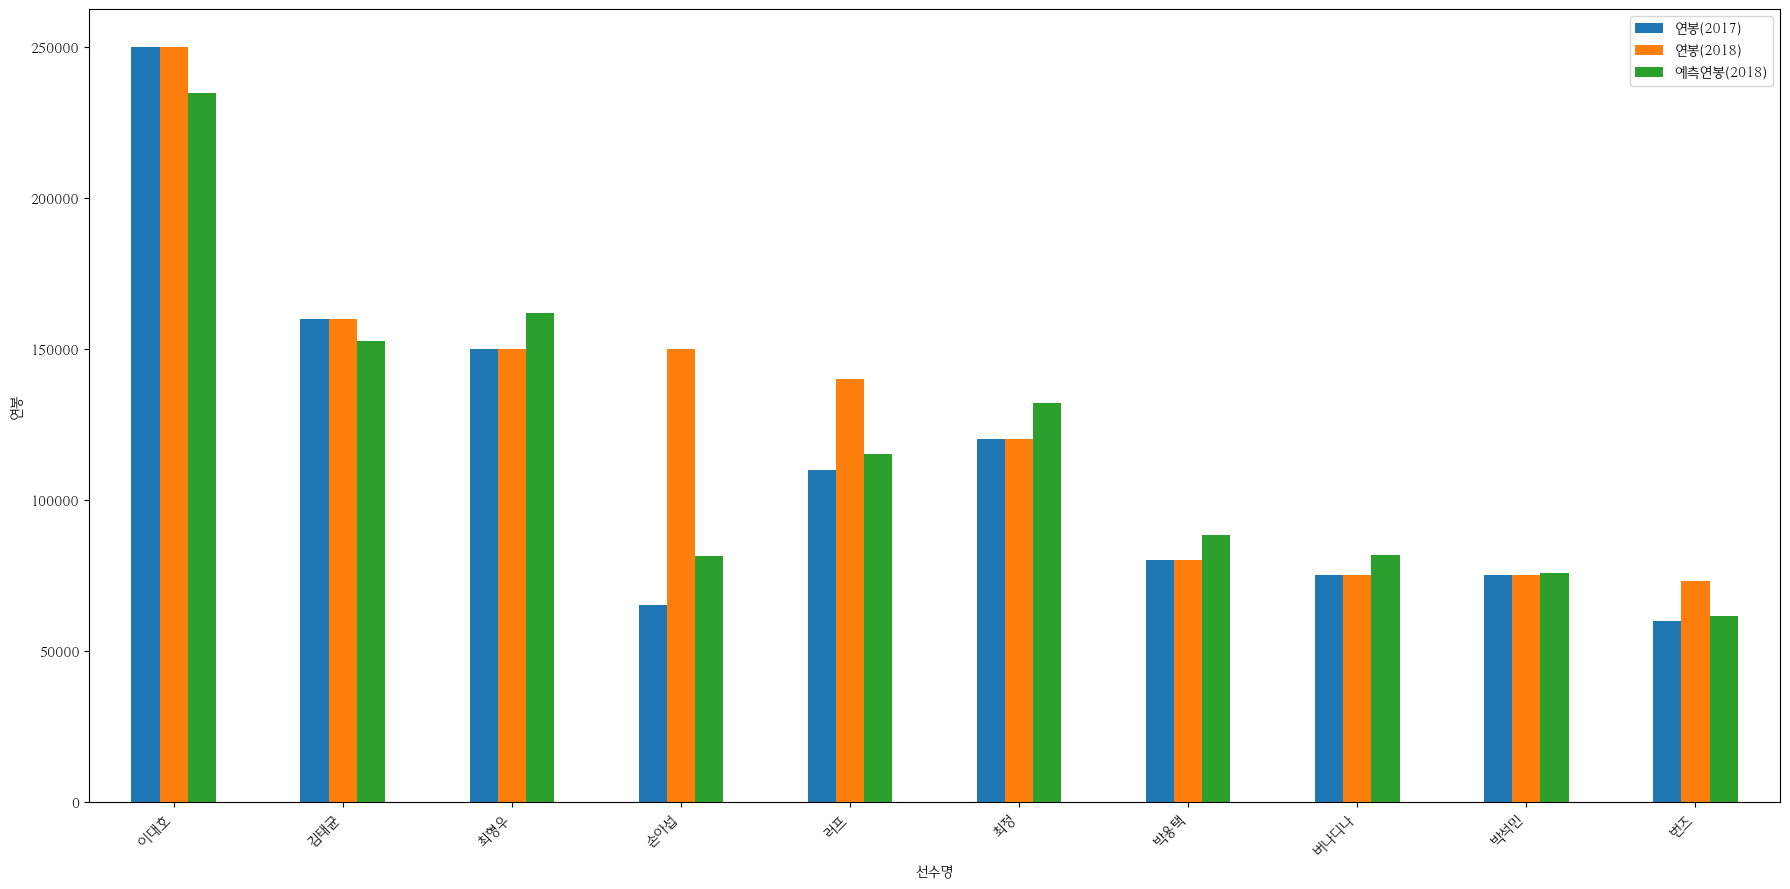

In [215]:
# 막대그래프는 선수가 너무 많으면 보기 힘드니까 실제 연봉 높은 순으로 일부만...
plot_df = salary_compare_df.sort_values("연봉(2018)", ascending=False).head(10)

ax = plot_df.plot(
    x="선수명",
    y=["연봉(2017)", "연봉(2018)", "예측연봉(2018)"],
    kind="bar",
    figsize=(18, 9)
)
ax.set_ylabel("연봉")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()


<Axes: xlabel='선수명'>

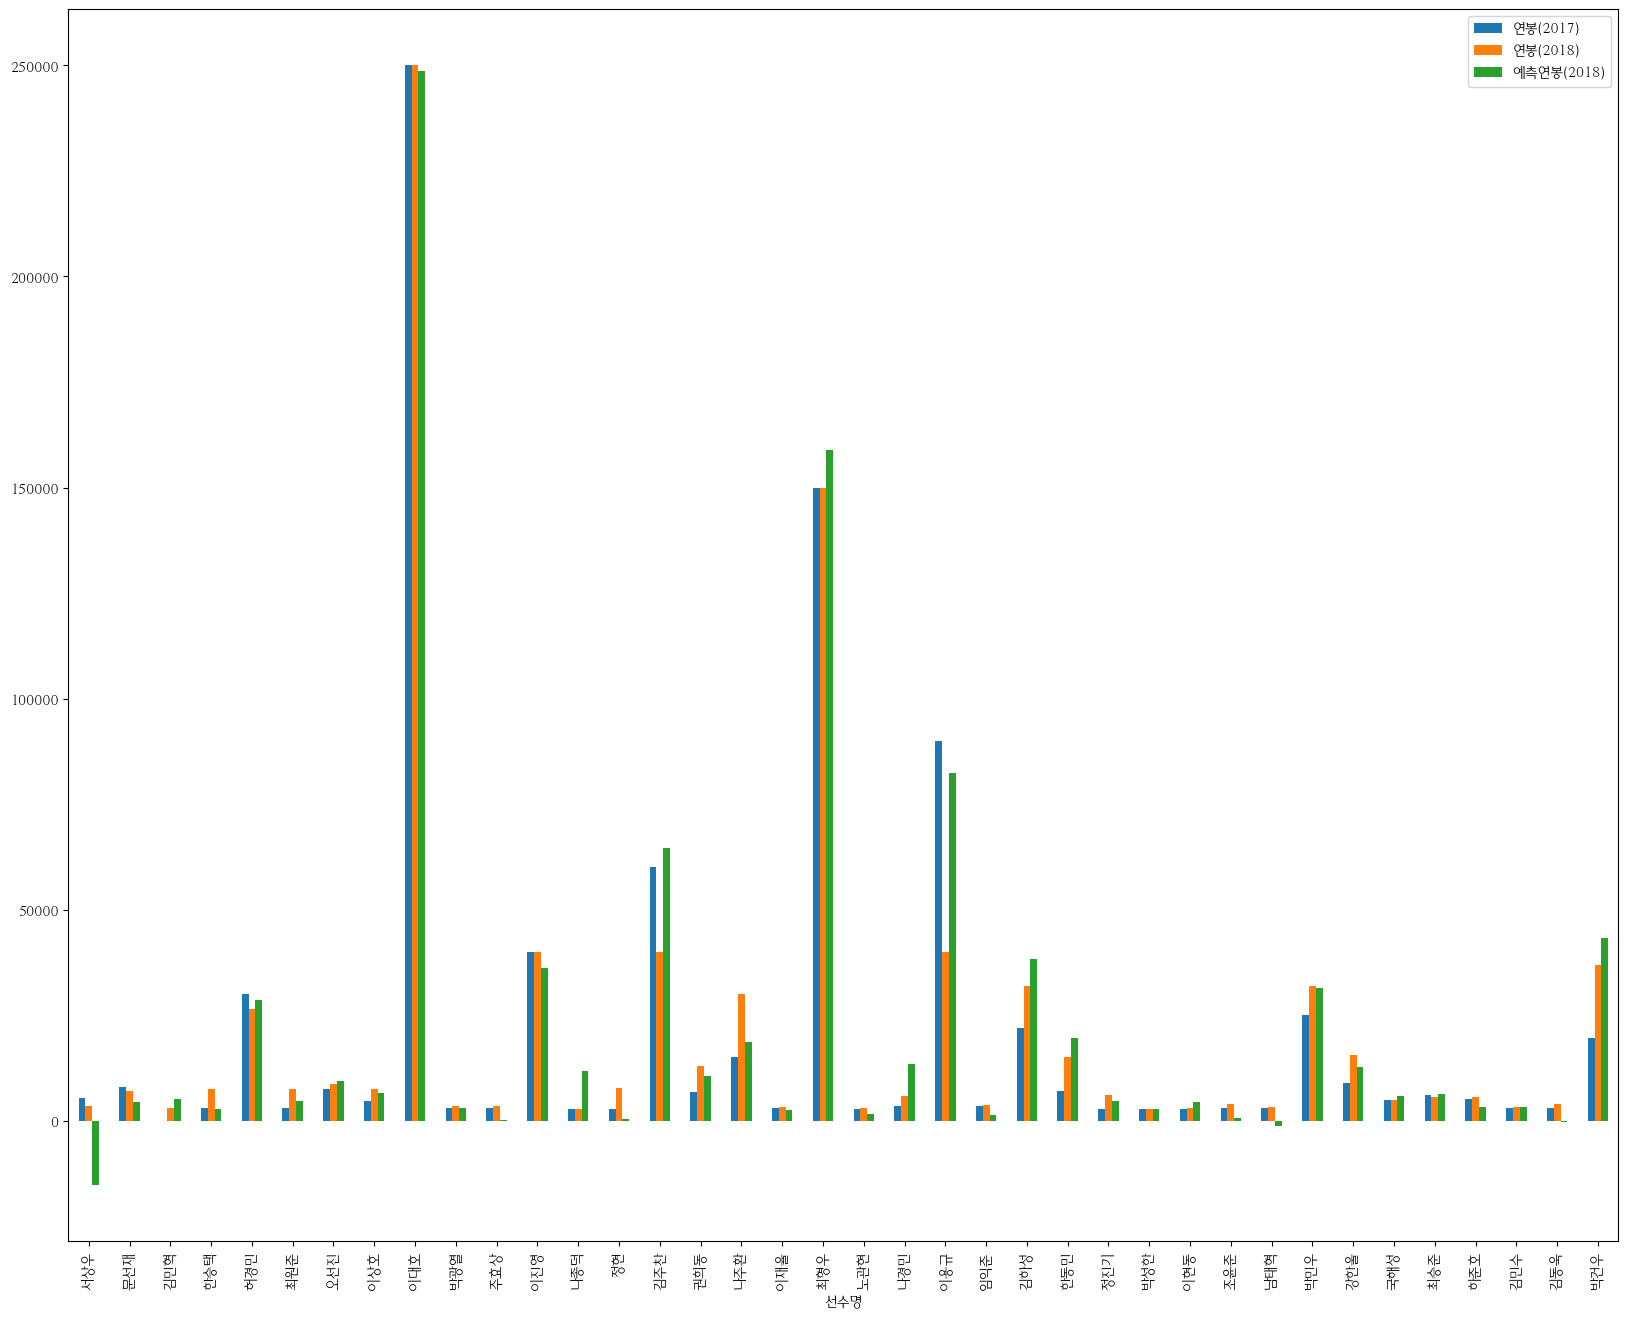

In [216]:
result_df.plot(x='선수명', y=["연봉(2017)", "연봉(2018)", "예측연봉(2018)"], kind="bar")
#원래는 이렇게 생김
#저렇게 서상우처럼 0 이하로 예측해버리는 오류도 있어서 오차가 발생하는듯... 회귀모델의 한계점이라고 보면 될거같다.
#이건 추후에 조건을 걸거나 Log을 써서 다시 해보면 좋을듯...